You are given a m x n matrix grid. Initially, you are located at the top-left corner (0, 0), and in each step, you can only move right or down in the matrix.

Among all possible paths starting from the top-left corner (0, 0) and ending in the bottom-right corner (m - 1, n - 1), find the path with the maximum non-negative product. The product of a path is the product of all integers in the grid cells visited along the path.

Return the maximum non-negative product modulo 109 + 7. If the maximum product is negative, return -1.

Notice that the modulo is performed after getting the maximum product.

 

Example 1:

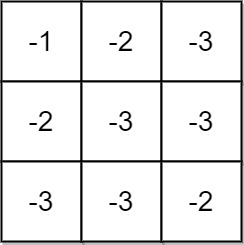

Input: grid = [[-1,-2,-3],[-2,-3,-3],[-3,-3,-2]]
Output: -1
Explanation: It is not possible to get non-negative product in the path from (0, 0) to (2, 2), so return -1.

Example 2:

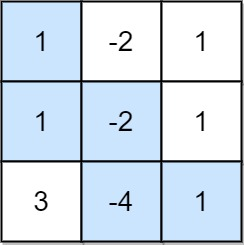

Input: grid = [[1,-2,1],[1,-2,1],[3,-4,1]]
Output: 8
Explanation: Maximum non-negative product is shown (1 * 1 * -2 * -4 * 1 = 8).

Example 3:

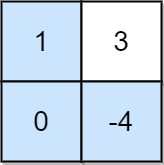

Input: grid = [[1,3],[0,-4]]
Output: 0
Explanation: Maximum non-negative product is shown (1 * 0 * -4 = 0).


In [ ]:
class Solution:
    def maxProductPath(self, grid: List[List[int]]) -> int:
        MOD = 10**9 + 7
        m, n = len(grid), len(grid[0])
        dp = [[[float("inf"), float("-inf")] for _ in grid[0]] for _ in grid]
        dp[0][0][0] = grid[0][0]
        dp[0][0][1] = grid[0][0]
        for i in range(1, n):
            v1, v2 = grid[0][i] * dp[0][i - 1][0], grid[0][i] * dp[0][i - 1][1]
            dp[0][i][0] = min(v1, v2)
            dp[0][i][1] = max(v1, v2)
        for i in range(1, m):
            v1, v2 = grid[i][0] * dp[i - 1][0][0], grid[i][0] * dp[i - 1][0][1]
            dp[i][0][0] = min(v1, v2)
            dp[i][0][1] = max(v1, v2)
        for i in range(1, m):
            for j in range(1, n):
                v1, v2 = grid[i][j] * dp[i - 1][j][0], grid[i][j] * dp[i - 1][j][1]
                v3, v4 = grid[i][j] * dp[i][j - 1][0], grid[i][j] * dp[i][j - 1][1]
                dp[i][j][0] = min(v1, v2, v3, v4)
                dp[i][j][1] = max(v1, v2, v3, v4)
        if dp[-1][-1][1] < 0:
            return -1
        return dp[-1][-1][1] % MOD
        